In [3]:
import json
import pandas as pd
import os
def gen_dataframe(s):
    l = []
    for fol in os.listdir(s):
        if not os.path.isdir(os.path.join(s, fol)):
                continue
        for folder in os.listdir(os.path.join(s, fol)):
            folder = os.path.join(s, fol, folder)
            if os.path.isdir(folder):
                with open(os.path.join(folder, "result.json"), "r") as f:
                    try:    
                        res = json.load(f)
                    except:
                        continue

                res.pop("config")
                with open(os.path.join(folder, "params.json"), "r") as f:
                    params = json.load(f)
                
                for k, v in params.items():
                    res[f"config/{k}"] = v

                l.append(res)
    df = pd.DataFrame(l)
    # df.to_pickle(os.path.join(s, "analysis_results.pkl"))
    return df
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

def hyper_params_heatmap(results, param_1_name, param_2_name, log_scale_1=True, 
                         log_scale_2=True, metric="val_acc", mode="max", log_metric=False):
    x = results[f"config/{param_1_name}"]
    y = results[f"config/{param_2_name}"]

    if log_scale_1:
        x = np.log10(x)
        param_1_name = "Exponent of: " + param_1_name
    if log_scale_2:
        y = np.log10(y)
        param_2_name = "Exponent of: " + param_2_name

    val = results[metric] 

    if log_metric:
        val = np.log(val)

    inter = LinearNDInterpolator((x, y), val)

    x_int = np.linspace(x.min(), x.max(), 1000)
    y_int = np.linspace(y.min(), y.max(), 1000)
    mesh = np.meshgrid(x_int, y_int)
    inter_val = inter(mesh)

    plt.imshow(inter_val, extent=[x_int[0], x_int[-1], y_int[0], y_int[-1]], origin="lower", aspect="auto")
    plt.colorbar()

    opt_ind = np.argmax(val) if mode == "max" else np.argmin(val)
    # plt.scatter(x, y)
    plt.scatter(x[opt_ind], y[opt_ind], c="r", marker="*", label=f"Optimum: {val[opt_ind]}")

    plt.xlabel(param_1_name)
    plt.ylabel(param_2_name)
    
    if log_metric:
        plt.title(f"Heatmap for: log({metric})")
    else:
        plt.title(f"Heatmap for: {metric}")
    plt.legend()

folder = r"Results2\slow_mo_m"#r"Results2\mini_batch_adamw\tune_distributed_learning_2025-01-19_22-36-14"
df = gen_dataframe(folder)

# hyper_params_heatmap(df, "local_opt.lr", "local_opt.weight_decay", True, True)#, "val_loss", "min", True)
# hyper_params_heatmap(df, "local_batch_size", "local_opt.lr", False, True, "val_acc", "max", False)
# hyper_params_heatmap(df, "n_workers", "n_local_steps", False, False, "test_acc")
# plt.savefig(os.path.join(folder, "heatmap_plot_loss.png"))

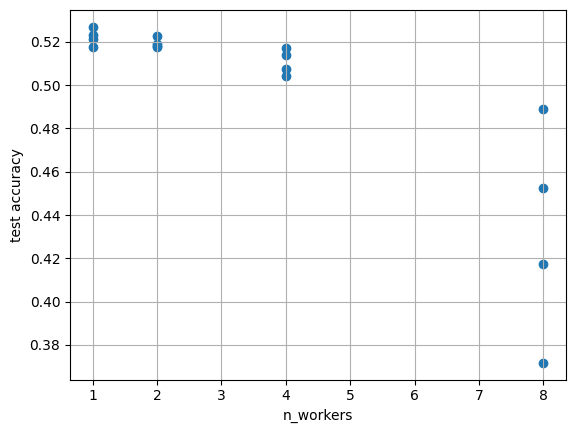

In [22]:
plt.scatter(df["config/n_workers"], df["test_acc"])
# plt.xscale("log")
# plt.xlabel("local learning rate")
plt.xlabel("n_workers")
plt.ylabel("test accuracy")
# opt_ind = np.argmax(df["val_acc"])
# plt.scatter(x, y)
# plt.scatter(df["config/local_opt.lr"][opt_ind], df["val_acc"][opt_ind], c="r", marker="*", label=f"Optimum: {df["val_acc"][opt_ind]}")
plt.grid()
plt.savefig(os.path.join(folder, "results.png"))

In [4]:
df.sort_values("val_acc", ascending=False)

,val_loss,val_acc,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,config/global_optimizer_class,config/local_batch_size,config/local_opt.lr,config/local_optimizer_class,config/n_epochs,config/n_local_steps,config/n_workers,config/scheduler.per_warmup_epochs,config/scheduler_class,config/test_mode
7,2.115916e+00,0.4846,1737503036,None,False,1,1cf68_00008,2025-01-22_00-43-56,1181.258220,1181.258220,...,<class 'optimizers.DoNothing'>,64,0.000526,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
4,2.138136e+00,0.4746,1737499373,None,False,1,1cf68_00004,2025-01-21_23-42-53,1200.325141,1200.325141,...,<class 'optimizers.DoNothing'>,64,0.001483,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
1,2.171784e+00,0.4554,1737495775,None,False,1,1cf68_00001,2025-01-21_22-42-55,1199.417134,1199.417134,...,<class 'optimizers.DoNothing'>,64,0.001876,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
5,2.509949e+00,0.3662,1737500646,None,False,1,1cf68_00006,2025-01-22_00-04-06,1178.544589,1178.544589,...,<class 'optimizers.DoNothing'>,64,0.000096,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
8,3.315255e+00,0.2078,1737504241,None,False,1,1cf68_00009,2025-01-22_01-04-01,1199.727015,1199.727015,...,<class 'optimizers.DoNothing'>,64,0.000024,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
2,3.430249e+00,0.1934,1737496961,None,False,1,1cf68_00002,2025-01-21_23-02-41,1179.998820,1179.998820,...,<class 'optimizers.DoNothing'>,64,0.000021,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
3,3.578372e+00,0.1588,1737498168,None,False,1,1cf68_00003,2025-01-21_23-22-48,1201.858873,1201.858873,...,<class 'optimizers.DoNothing'>,64,0.000016,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
10,3.895007e+00,0.1118,1737506633,None,False,1,1cf68_00011,2025-01-22_01-43-53,1201.107388,1201.107388,...,<class 'optimizers.DoNothing'>,64,0.011040,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
6,4.105681e+00,0.0822,1737501850,None,False,1,1cf68_00007,2025-01-22_00-24-10,1198.784069,1198.784069,...,<class 'optimizers.DoNothing'>,64,0.000004,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False
0,4.173929e+00,0.0726,1737494570,None,False,1,1cf68_00000,2025-01-21_22-22-50,1178.080877,1178.080877,...,<class 'optimizers.DoNothing'>,64,0.000003,<class 'optimizers.LARS'>,150,1,1,0.055556,<class 'optimizers.WarmupCosineAnnealing'>,False


In [11]:
import statsmodels.api as sm


def control_for(df, name, metric, log=False):
    
    coeffs = sm.OLS(df[metric], sm.add_constant(df[])).fit().params

    return df[metric] + coeffs[f"config/{name}"] * (df[f"config/{name}"].mean() - df[f"config/{name}"])


plt.scatter(df["config/n_local_steps"], control_for(df, "n_workers", "val_loss"))

In [ ]:
import numpy as np
np.random.permutation(10)

In [ ]:
df.filter(["config/local_opt.lr", "config/local_opt.weight_decay", "val_loss"]).sort_values("val_loss")#.sort_values("val_acc", ascending=False)

In [ ]:
[2**i for i in range(1, 9)]